## Quantization

- FP-16 --> Floating Point 16 --> 16 bits to store a decimal number

- Storing every weight/activation/gradient in a 4 byte float is expensive
- So we need quantization techniques to improve latency and memory usage

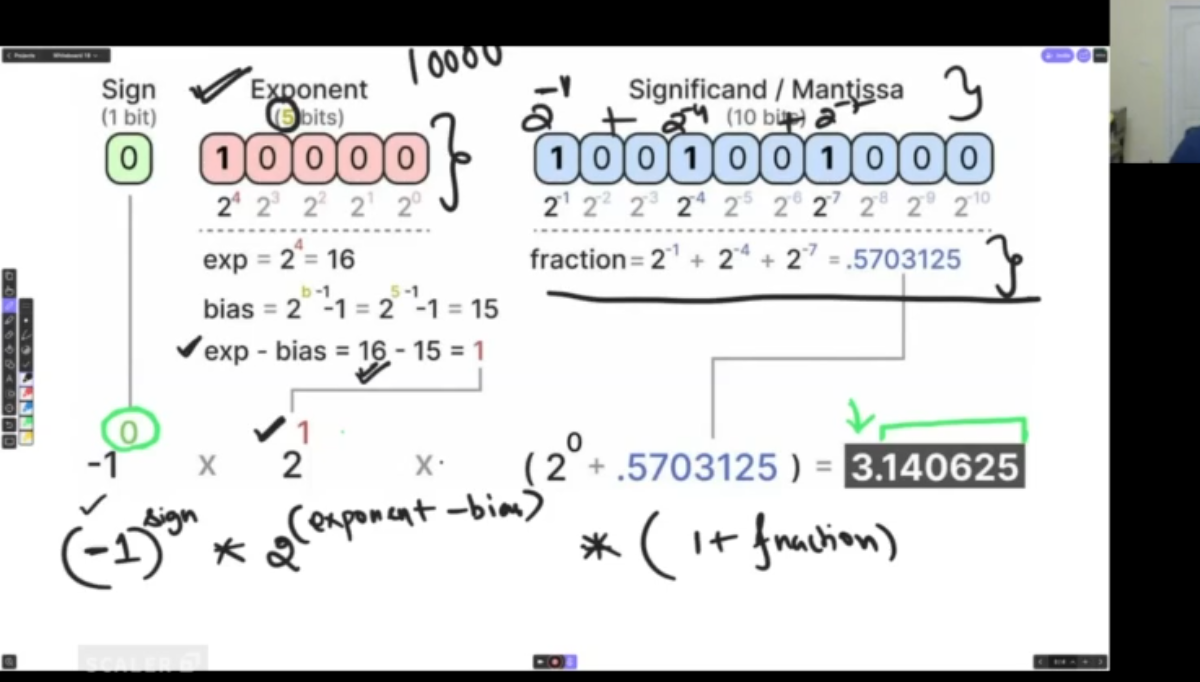

- Bias --> Fixed by floating point format

- bias = 2^(b-1) - 1
    - b = number of bits for exponent

- BF16 --> lower memory than FP32 and higher range than FP16

## Quantization 

- Convert FP32 to FP16/BF16 Format 

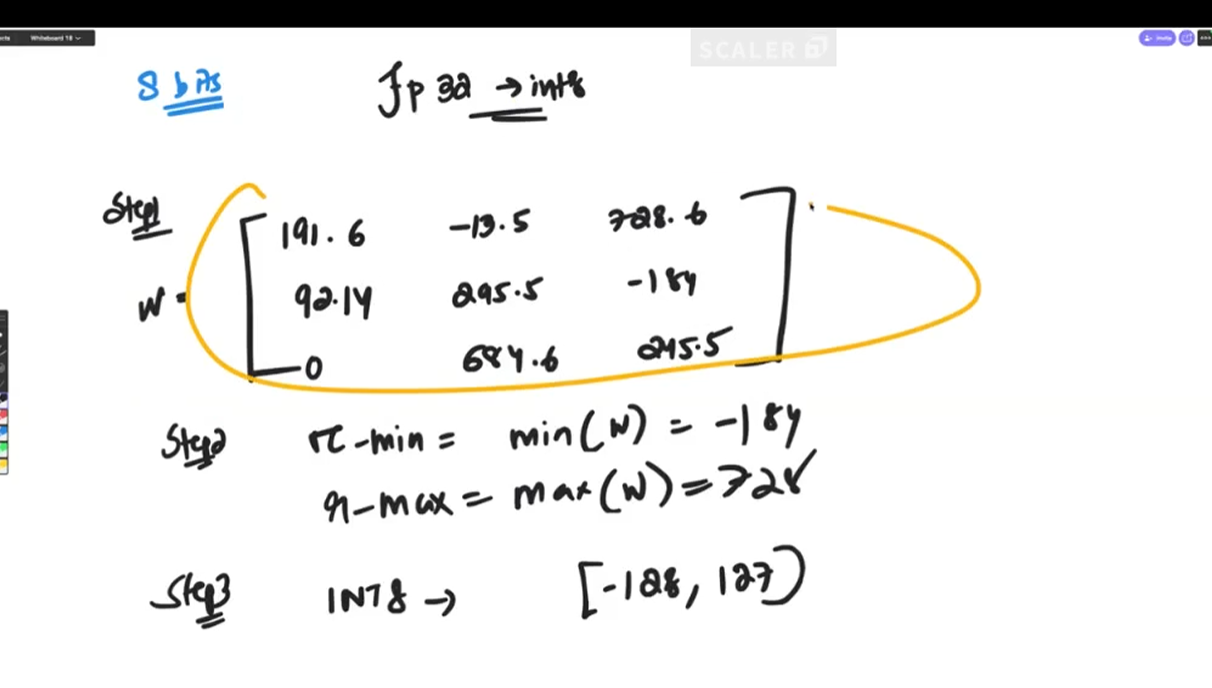

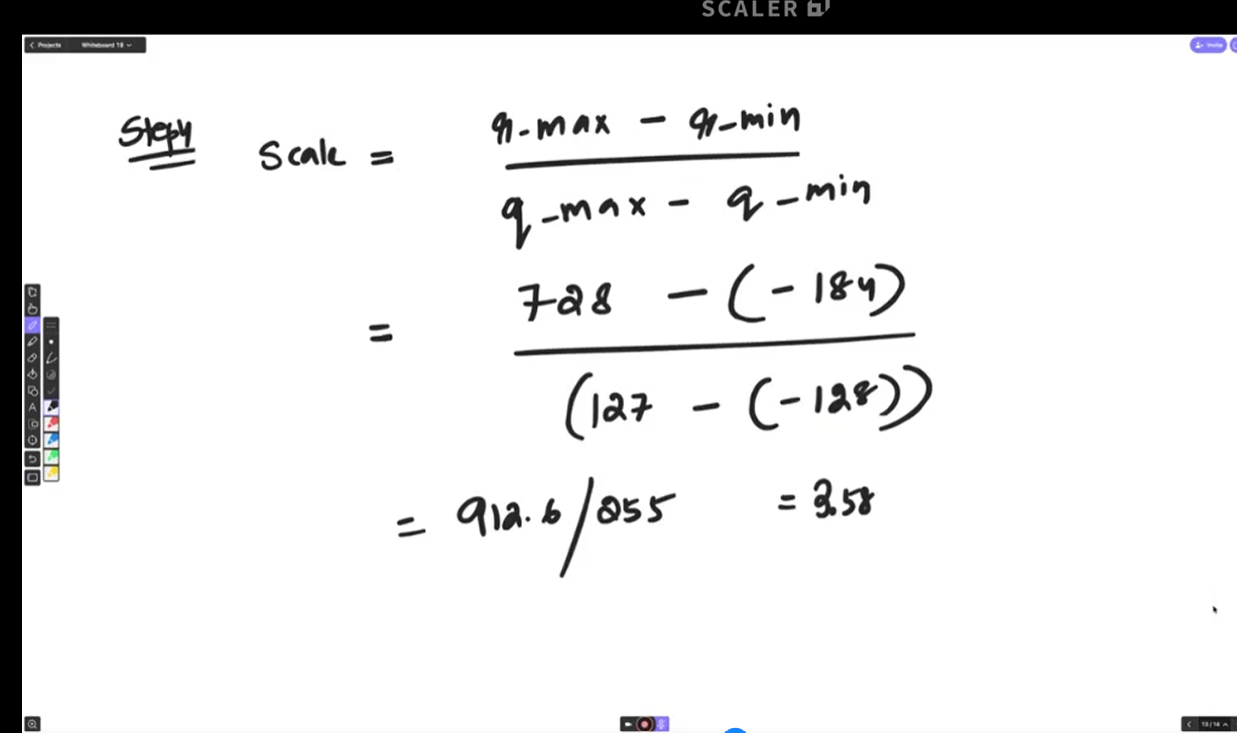

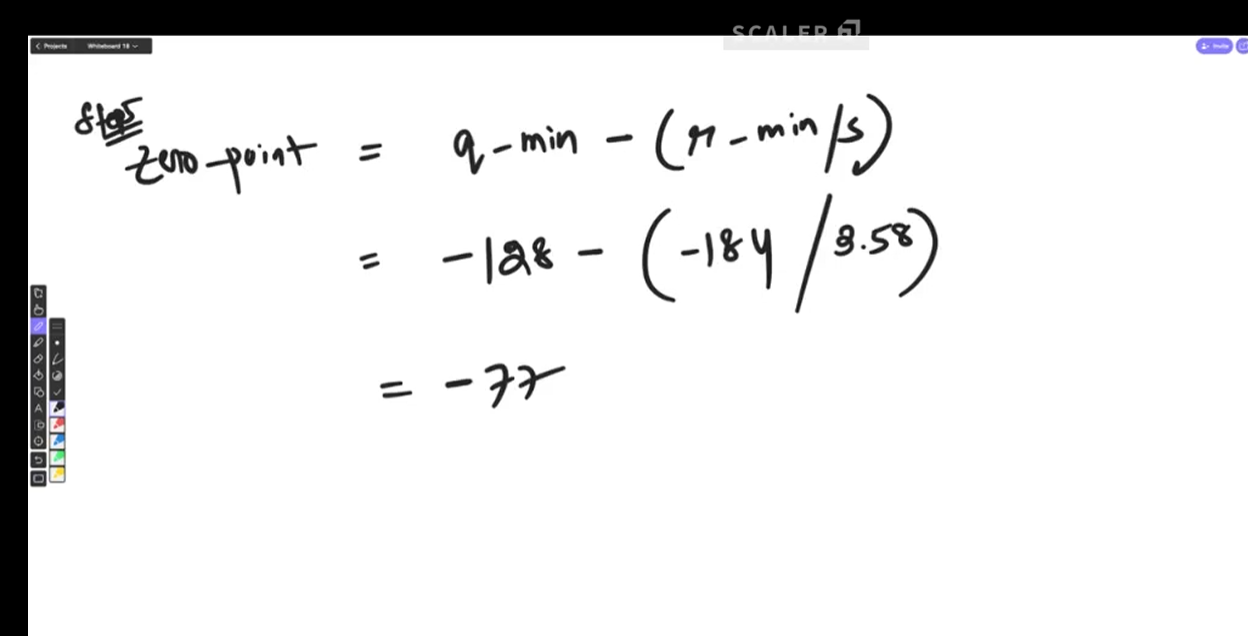

FP32            INT8/FP16/BF16(BASED ON OUR CHOICE)
|                   |   
|                   |
r  =   scale x (quantized value - zero_point)
|
|
original value 

- scale = (r_max - r_min) / (q_max - q_min)
- zero_point = q_min - (r_min / scale)

- So, to calculate quantized value from original , we use this -->
    - quantized_value = (original_value / scale) + zero_point

- quantized_value = clip ( round((original_value / scale)) + zero_point , q_min , q_max )

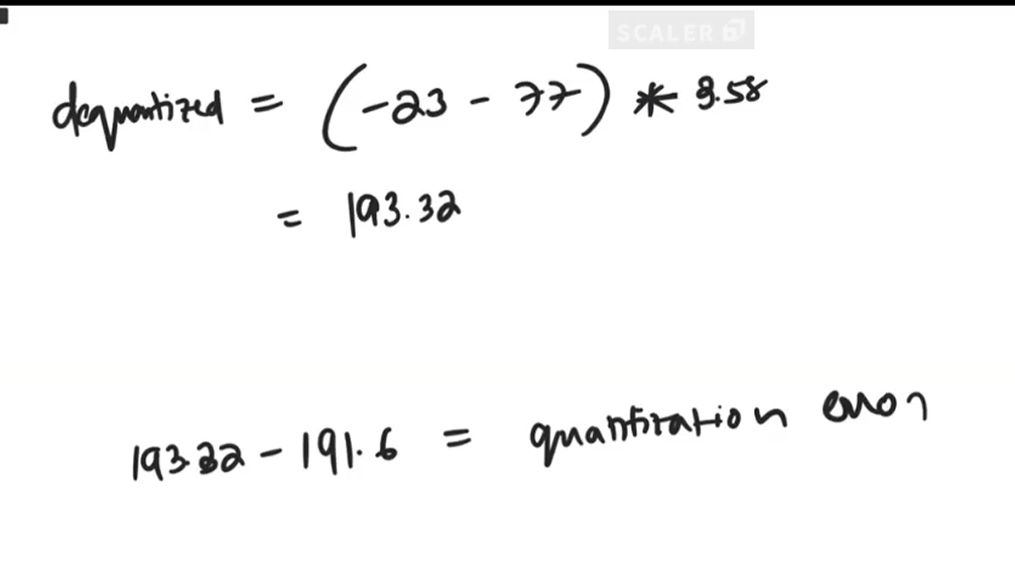


| Concept | Key Point |
|---|---|
| **Quantization** | Reduce bit-width of model parameters to save memory and speed up inference |
| **Symmetric (absmax)** | Zero maps to zero. Scale = max(abs(x)) / q_max |
| **Asymmetric (zero-point)** | Shifts zero point. Better for skewed distributions |
| **Per-tensor** | One scale for the whole tensor. Fast but less precise |
| **Per-channel** | One scale per row/column. Good accuracy/overhead balance |
| **Per-group** | One scale per group. Most precise, most storage overhead |
| **PTQ (Dynamic)** | Compute scale/zp at runtime per layer |
| **PTQ (Static)** | Pre-compute scale/zp with calibration dataset |
| **QAT** | Simulate quantization during training. Finds wide minima |
| **GPTQ** | Layer-wise PTQ with inverse Hessian error redistribution. GPU-focused |
| **GGUF** | Block-wise quantization. CPU+GPU hybrid |
| **BitNet** | 1-bit weights (-1, 1). Signum function quantization |
| **BitNet 1.58b** | Ternary weights (-1, 0, 1). Replaces multiplication with addition |